## Know your libraries (KYL)

In [1]:
import sys
sys.path.append('../../../src')

import multiprocessing as mp
mp.set_start_method('spawn', force=True)

import dataset, molecular_representation, config, utils, model
from dataset import QM9Dataset,LogSDataset,LogPDataset,FreeSolvDataset,ESOLDataset,ToxQDataset
import numpy as np
import pandas as pd
from utils import *
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from model import AtomAutoencoder,BondAutoencoder
from model import GNNBondAngle,GNN2D,GNN3D,GNN3DAtnON,GNN3DAtnOFF,GNN3Dihed,GNN3DConfig,GNN3DLayer,GNN3DClassifier

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG=True
IPythonConsole.drawOptions.addStereoAnnotation = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc

import os
datadir="../../../data/regression/qm9_cust_conf/"
#modeldir="./models/"
#modeldir=os.path.join(datadir, "models")
modeldir="../../../train/regression/qm9_cust_conf/models"
dataset_name="qm9"
# Create datadir and modeldir folders if they don't exist
if not os.path.exists(datadir):
    os.makedirs(datadir)

if not os.path.exists(modeldir):
    os.makedirs(modeldir)

import time
import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Know your correlations (KYC)

In [2]:
# Calculate R^2
def calculate_r_squared(predictions, targets):
    ss_tot = np.sum((targets - np.mean(targets))**2)
    ss_res = np.sum((targets - predictions)**2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared

## Know your modules (KYM)

In [3]:
class CustomMoleculeDataset(Dataset):
    """A custom dataset class to work DataLoader"""
    def __init__(self, samples, atom_autoencoder, bond_autoencoder, device):
        self.samples = samples
        self.atom_autoencoder = atom_autoencoder
        self.bond_autoencoder = bond_autoencoder
        self.device = device

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        processed_data = process_molecule(sample, self.atom_autoencoder, self.bond_autoencoder, self.device)

        if processed_data is None:
            return (None,) * 9

        if len(processed_data) != 9:
            raise ValueError(f"Unexpected number of elements: {len(processed_data)}")


        return processed_data




def process_molecule(molecule, atom_autoencoder, bond_autoencoder, device):
    """Separate input features and target"""
    if len(molecule) < 9:
        return None

    # Extracting features and target (9th element (index 8) is the target)
    target = molecule[8]
    molecule_data = [mol_elem for mol_elem in molecule[:8]]

    atom_features = molecule_data[0]
    bond_features = molecule_data[1]

    if len(atom_features) == 0 or len(bond_features) == 0:
        return None

   #molecule_data = [item.to(device) for item in molecule_data]
    molecule_data = [item.to(device).detach() for item in molecule_data]
    # Applying encoders
    molecule_data[0] = atom_autoencoder.encode(molecule_data[0])
    molecule_data[1] = bond_autoencoder.encode(molecule_data[1])


    # Moving data to the device in the training loop
    return molecule_data[0], molecule_data[1], molecule_data[2], molecule_data[3], molecule_data[4], molecule_data[5], molecule_data[6], molecule_data[7], target




def collate_fn(batch):
    """Custom collate function for batching molecular data."""


    # Filter out None values
    batch = [item for item in batch if item[0] is not None]

    # If all samples were skipped, return empty tensors
    if not batch:
        return (torch.empty(0),) * 8 + (torch.empty(0),)

    # Extract components from batch
    atomic_features = [item[0] for item in batch]
    bond_features = [item[1] for item in batch]
    angle_features = [item[2] for item in batch]
    dihedral_features = [item[3] for item in batch]
    global_molecular_features = [item[4] for item in batch]
    bond_indices = [item[5] for item in batch]
    angle_indices = [item[6] for item in batch]
    dihedral_indices = [item[7] for item in batch]
    targets = [item[8] for item in batch]

    # Determine the device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Convert all tensors to detach and ensure they are on the same device
    def detach_and_to_device(tensors, device):
        return [tensor.detach().to(device) for tensor in tensors]

    device = atomic_features[0].device if atomic_features else 'cpu'
    atomic_features = detach_and_to_device(atomic_features, device)
    bond_features = detach_and_to_device(bond_features, device)
    angle_features = detach_and_to_device(angle_features, device)
    dihedral_features = detach_and_to_device(dihedral_features, device)
    global_molecular_features = detach_and_to_device(global_molecular_features, device)
    targets = detach_and_to_device(targets, device)

    # Pad sequences and stack
    def pad_sequences(sequences):
        lengths = [seq.size(0) for seq in sequences]
        max_len = max(lengths, default=0)
        return pad_sequence(sequences, batch_first=True, padding_value=0), max_len

    atomic_features, _ = pad_sequences(atomic_features)
    bond_features, max_bond_len = pad_sequences(bond_features)
    angle_features, max_angle_len = pad_sequences(angle_features)
    dihedral_features, max_dihedral_len = pad_sequences(dihedral_features)
    global_molecular_features = torch.stack(global_molecular_features)
    targets = torch.stack(targets)

    # Pad indices
    def pad_indices(indices_list, max_len):
        padded_indices = torch.full((len(indices_list), max_len, 2), -1, dtype=torch.long)
        for i, indices in enumerate(indices_list):
            if indices.size(0) > 0:
                end = min(indices.size(0), max_len)
                padded_indices[i, :end] = indices[:end]
        return padded_indices

    bond_indices = pad_indices(bond_indices, max_bond_len)
    angle_indices = pad_indices(angle_indices, max_angle_len)
    dihedral_indices = pad_indices(dihedral_indices, max_dihedral_len)

    # Create a batch and move to device
    batch_tensors = (
        atomic_features, bond_features, angle_features, dihedral_features,
        global_molecular_features, bond_indices, angle_indices, dihedral_indices,
        targets
    )

    # Move all tensors to the device
    batch_tensors = tuple(tensor.to(device) for tensor in batch_tensors)

    return batch_tensors
   #return atomic_features, bond_features, angle_features, dihedral_features, global_molecular_features, bond_indices, angle_indices, dihedral_indices, targets




def train_gnn3d_model(gnn3d, train_samples, val_samples, test_samples, atom_autoencoder, bond_autoencoder, n_epochs=10, printstep=10, save_dir="./models/", dataset_name="logs", batch_size=16, prefetch_factor=2, num_workers=0):
    """Train GNN3D"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(save_dir, exist_ok=True)
    mse_loss_fn = torch.nn.MSELoss()
    gnn_optimizer = torch.optim.Adam(gnn3d.parameters(), lr=1e-3)

    dataloader_train = DataLoader(
        CustomMoleculeDataset(train_samples, atom_autoencoder, bond_autoencoder, device=device),
        batch_size=batch_size,
        prefetch_factor=prefetch_factor,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
        collate_fn=collate_fn
    )

    dataloader_val = DataLoader(
        CustomMoleculeDataset(val_samples, atom_autoencoder, bond_autoencoder, device=device),
        batch_size=batch_size,
        prefetch_factor=prefetch_factor,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
        collate_fn=collate_fn
    )

    dataloader_test = DataLoader(
        CustomMoleculeDataset(test_samples, atom_autoencoder, bond_autoencoder, device=device),
        batch_size=batch_size,
        prefetch_factor=prefetch_factor,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
        collate_fn=collate_fn
    )

    gnn3d.load_state_dict(torch.load(os.path.join(save_dir, f"gnn3d_{dataset_name}.pth")))

    gnn3d.eval()

    # Evaluation on test samples
    avg_rmse_loss_test = 0
    avg_mse_loss_test = 0
    total_samples_test = 0
    skipped_samples_test = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for batch in tqdm(dataloader_test, desc='Test samples'):

            # Filter out None values
            batch = [item for item in batch if item is not None]
            if not batch:
                skipped_samples_test += len(batch)
                continue

            atomic_features, bond_features, angle_features, dihedral_features, global_molecular_features, bond_indices, angle_indices, dihedral_indices, targets_batch = batch

            valid_indices = [i for i, target in enumerate(targets_batch) if target is not None]
            if not valid_indices:
                skipped_samples_test += len(targets_batch)
                continue
            # Only retain valid samples
            atomic_features = atomic_features[valid_indices]
            bond_features = bond_features[valid_indices]
            angle_features = angle_features[valid_indices]
            dihedral_features = dihedral_features[valid_indices]
            global_molecular_features = global_molecular_features[valid_indices]
            bond_indices = bond_indices[valid_indices]
            angle_indices = angle_indices[valid_indices]
            dihedral_indices = dihedral_indices[valid_indices]
            targets_batch = targets_batch[valid_indices]

            # Forward pass
            for i in range(len(targets_batch)):
                molecule_data = (atomic_features[i], bond_features[i], angle_features[i], dihedral_features[i], global_molecular_features[i], bond_indices[i], angle_indices[i], dihedral_indices[i])  # atom-bond-angle-dihedral
               #molecule_data = (bond_features[i], angle_features[i], global_molecular_features[i], angle_indices[i])  #bond-angle
               #molecule_data = (atomic_features[i], bond_features[i], global_molecular_features[i], bond_indices[i])  #atom-bond

                target = targets_batch[i]

                prediction = gnn3d(molecule_data)
                loss = mse_loss_fn(prediction, target)

                # Extract target and prediction values
                predictions.append(prediction.item())
                targets.append(target.item())

                avg_mse_loss_test += loss.item()
                avg_rmse_loss_test += torch.sqrt(loss).item()
                total_samples_test += 1

    # Calculate average losses for test
    avg_mse_loss_test /= total_samples_test
    avg_rmse_loss_test /= total_samples_test

    print(f"Test Results:")
    print(f"RMSE Loss: {avg_rmse_loss_test:.4f}")
    print(f"MSE Loss: {avg_mse_loss_test:.4f}")

    return predictions, targets

## Know your variables for main()

In [4]:
def main():
    """Function for train, validation and test
       Make sure to assign your local variables here too"""
    mp.set_start_method('spawn', force=True)

    datadir="../../../data/regression/qm9_cust_conf/"
    #modeldir="./models/"
    modeldir="../../../train/regression/qm9_cust_conf/models"
    dataset_name="qm9"

    train_samples = QM9Dataset(datadir+"train")
    print(train_samples)
    print("===================================")
    test_samples = QM9Dataset(datadir+"test")
    print(test_samples)
    print("===================================")

   #subset_size = 200
   #subset_indices = list(range(min(subset_size, len(train_samples))))
   #subset_samples = Subset(train_samples, subset_indices)

    n_epochs=10
    printstep=2
    batch_size=1
    prefetch_factor=None
    num_workers=0

    random_state_values = [98] #, 123, 456, 1704, 19472]

    for random_state in random_state_values:

        print(f"Testing for random_state = {random_state}")

        gnn3d = GNN3Dihed(atomic_vector_size=46, bond_vector_size=3, number_of_molecular_features=200, number_of_targets=1).to(device)
        train_part_samples, val_samples = train_test_split(train_samples, test_size=0.1, random_state=random_state)
       #train_part_samples, val_samples = train_test_split(subset_samples, test_size=0.1, random_state=random_state)
        atom_autoencoder = AtomAutoencoder(154, 46).to(device)
        bond_autoencoder = BondAutoencoder(10, 3).to(device)

        predictions, targets=train_gnn3d_model(
            gnn3d,
            train_part_samples,
            val_samples,
            test_samples,
            atom_autoencoder,
            bond_autoencoder,
            n_epochs=n_epochs,
            printstep=printstep,
            save_dir=modeldir,
            dataset_name=dataset_name,
            batch_size=batch_size,
            prefetch_factor=prefetch_factor,
            num_workers=num_workers
        )


    return gnn3d, predictions, targets

## Training=================================================
## GNN3D training for multiple models; and testing

Loading dataset from folder
Initializing Molecular Representation Generator
Dataset Name: QM9
Number of Molecules Loaded: 810
Loading dataset from folder
Initializing Molecular Representation Generator
Dataset Name: QM9
Number of Molecules Loaded: 90
Testing for random_state = 98


Test samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:00<00:00, 265.12it/s]


Test Results:
RMSE Loss: 0.0228
MSE Loss: 0.0010
Pearson Correlation Coefficient: 0.8177
Coefficient of Determination R^2: 0.5881
Filtered Predictions shape: (89,)
Filtered Targets shape: (89,)
Pearson Correlation Coefficient after removing outlier: 0.8577
Coefficient of Determination R² after removing outlier: 0.6691


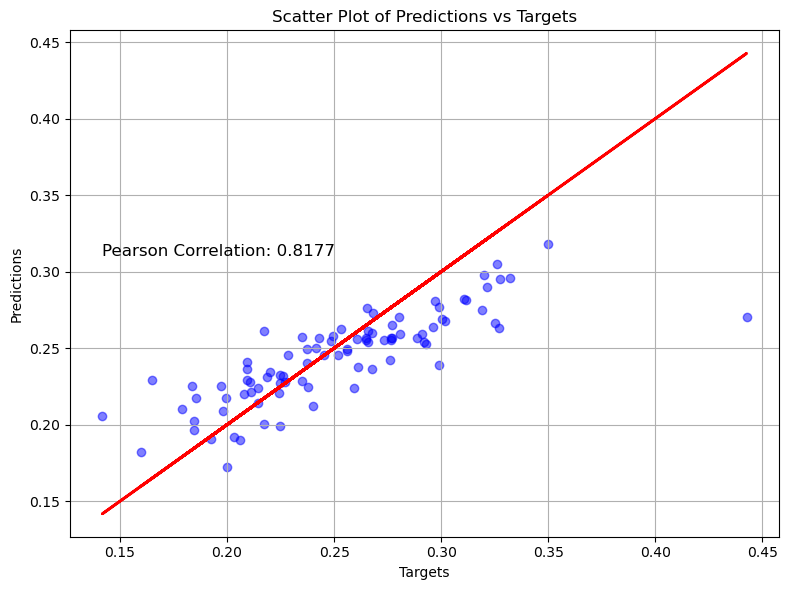

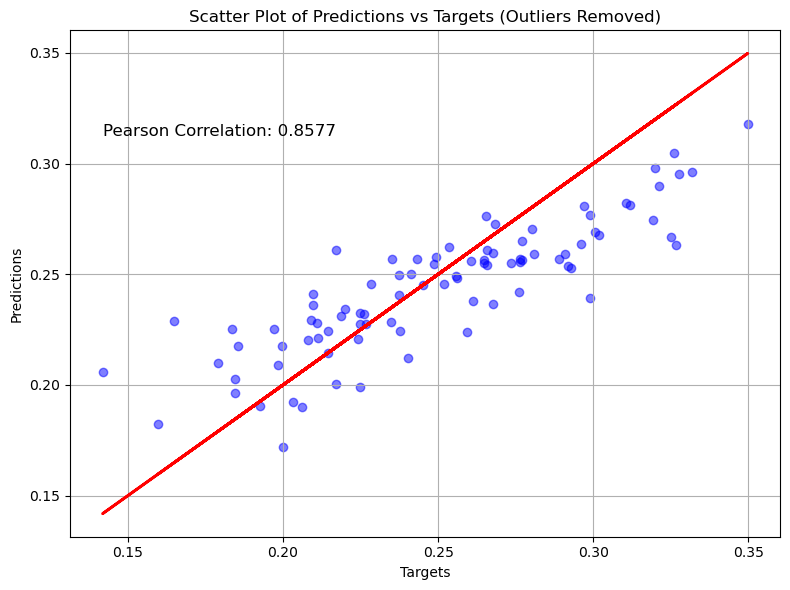

In [5]:
if __name__ == '__main__':
    gnn3d, predictions, targets = main()

## Know your correlations (KYC) before deleting outliers====

    # Convert lists to NumPy arrays
    predictions = np.array(predictions)
    targets = np.array(targets)

    # Calculate Pearson correlation coefficient
    corr, _ = pearsonr(predictions, targets)

    print(f"Pearson Correlation Coefficient: {corr:.4f}")

    r_squared = calculate_r_squared(predictions, targets)
    print(f"Coefficient of Determination R^2: {r_squared:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(targets, predictions, color='blue', alpha=0.5)
    plt.plot(targets, targets, color='red', linestyle='-', linewidth=2)  # Plot y=x line
    plt.text(np.min(targets), np.max(predictions), f"Pearson Correlation: {corr:.4f}", fontsize=12, verticalalignment='top')
    plt.title('Scatter Plot of Predictions vs Targets')
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{modeldir}gnn3d_scatter_{dataset_name}_predictions_targets.png")
    plt.savefig(f"{modeldir}gnn3d_scatter_{dataset_name}_predictions_targets.svg", format='svg')


## Know your structures (KYS)===============================
    '''Test data WITH SKIP starts
       USE this if you have <translated_smiles.npy> file'''
    molecules = np.load(datadir + 'test/translated_smiles.npy')
    results = pd.DataFrame({
        'y_true': targets,
        'y_pred': predictions,
        'smiles': molecules
    })
    ## Test data WITH SKIP ends

   #'''Test data ZERO SKIP starts
   #   USE this if you don't have <translated_smiles.npy> file'''
   #test_dataset = pd.read_csv(datadir + "test.csv")
   #molecules = test_dataset['smiles']
   #results = pd.DataFrame({
   #    'y_true': targets,
   #    'y_pred': predictions,
   #    'smiles': molecules
   #})
   ### Test data ZERO SKIP ends


    results.to_csv(modeldir + 'results_true_pred_smiles.csv', index=False, float_format='%.4f')

    results['absolute_error'] = abs(results['y_true'] - results['y_pred'])

    top_least_predicted = results.nlargest(10, 'absolute_error')

    top_best_predicted = results.nsmallest(10, 'absolute_error')

    top_least_predicted_smiles = results['smiles'].iloc[top_least_predicted.index].apply(lambda x: Chem.MolFromSmiles(x))
    top_least_predicted_y_true = top_least_predicted['y_true'].tolist()
    top_least_predicted_y_pred = top_least_predicted['y_pred'].tolist()
    top_least_predicted_abs_error = top_least_predicted['absolute_error'].tolist()
    least_predicted_legends = [f"True: {top_least_predicted_y_true[i]:.4f}, Pred: {top_least_predicted_y_pred[i]:.4f} (Error: {top_least_predicted_abs_error[i]:.4f})" for i in range(len(top_least_predicted))]

    least_predicted_img = Draw.MolsToGridImage(top_least_predicted_smiles, molsPerRow=5, maxMols=10, legends=least_predicted_legends, useSVG=True)
    least_predicted_svg = least_predicted_img.data
    with open(f"./{modeldir}/{dataset_name}_top_least_predicted_mols_to_grid.svg", "w") as f:
        f.write(least_predicted_svg)

    top_best_predicted_smiles = results['smiles'].iloc[top_best_predicted.index].apply(lambda x: Chem.MolFromSmiles(x))
    top_best_predicted_y_true = top_best_predicted['y_true'].tolist()
    top_best_predicted_y_pred = top_best_predicted['y_pred'].tolist()
    top_best_predicted_abs_error = top_best_predicted['absolute_error'].tolist()
    best_predicted_legends = [f"True: {top_best_predicted_y_true[i]:.4f}, Pred: {top_best_predicted_y_pred[i]:.4f} (Error: {top_best_predicted_abs_error[i]:.4f})" for i in range(len(top_best_predicted))]

    best_predicted_img = Draw.MolsToGridImage(top_best_predicted_smiles, molsPerRow=5, maxMols=10, legends=best_predicted_legends, useSVG=True)
    best_predicted_svg = best_predicted_img.data
    with open(f"./{modeldir}/{dataset_name}_top_best_predicted_mols_to_grid.svg", "w") as f:
        f.write(best_predicted_svg)


## Know your correlations (KYC) after deleting outliers====
   #least_predicted_indices = top_least_predicted.index.tolist()
    least_predicted_indices = worst_outlier_index = top_least_predicted['absolute_error'].idxmax()

    filtered_results = results.drop(index=least_predicted_indices)

    filtered_predictions = filtered_results['y_pred'].values
    filtered_targets = filtered_results['y_true'].values

    print("Filtered Predictions shape:", filtered_predictions.shape)
    print("Filtered Targets shape:", filtered_targets.shape)

    corr_after_removal, _ = pearsonr(filtered_predictions, filtered_targets)
    r_squared_after_removal = calculate_r_squared(filtered_predictions, filtered_targets)

    print(f"Pearson Correlation Coefficient after removing outlier: {corr_after_removal:.4f}")
    print(f"Coefficient of Determination R² after removing outlier: {r_squared_after_removal:.4f}")


    plt.figure(figsize=(8, 6))
    plt.scatter(filtered_targets, filtered_predictions, color='blue', alpha=0.5)
    plt.plot(filtered_targets, filtered_targets, color='red', linestyle='-', linewidth=2)  # Plot y=x line
    plt.text(np.min(filtered_targets), np.max(filtered_predictions), f"Pearson Correlation: {corr_after_removal:.4f}", fontsize=12, verticalalignment='top')
    plt.title('Scatter Plot of Predictions vs Targets (Outliers Removed)')
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{modeldir}gnn3d_scatter_{dataset_name}_predictions_targets_cleaned.png")
    plt.savefig(f"{modeldir}gnn3d_scatter_{dataset_name}_predictions_targets_cleaned.svg", format='svg')

## Custom Conformations

In [8]:
from molecular_representation import MolecularGraphGeneratorConfig, MolecularGraphGenerator

# We instantiate the configuration class and the molecular generator

config = MolecularGraphGeneratorConfig()
generator = MolecularGraphGenerator(config)

Initializing Molecular Representation Generator


In [12]:
# Say we want to make a representation of ethane in the staggered state.
# Then we can use the molecular graph generator to create a base representation for us.
# We will then modify the appropriate dihedral angle values to put it in the staggard state

success, representation = generator.smiles_to_molecular_representation('CC')
if not success:
    raise RuntimeError("Failed to generate molecular representation.")

print(f"Original dihedral_features:")
print(representation[-3])

def modify_dihedral_angle(molecular_representation, 
                         atom1_idx, atom2_idx, atom3_idx, atom4_idx, 
                         dihedral_angle):
    """
    Returns a modified version of the graph representation so that the dihedral 
    angle corresponding to (atom1_idx, atom2_idx, atom3_idx, atom4_idx) is set
    to `dihedral_angle`, and the reverse direction 
    (atom4_idx, atom3_idx, atom2_idx, atom1_idx) is set to the 'mirror' of that 
    angle (commonly -dihedral_angle).
    """

    # Unpack the molecular representation
    (atomic_features, bond_features, bond_indices,
     angle_features, angle_indices,
     dihedral_features, dihedral_indices,
     global_molecular_features) = molecular_representation

    # Helper function: given a dihedral index, recover which four atoms define it
    def get_atoms_for_dihedral(d_idx):
        """
        Each entry in dihedral_indices is something like [angle_i, angle_j].
        Each angle_i (and angle_j) is an index into angle_indices,
        which itself is something like [bond_A, bond_B].
        Each bond_A or bond_B is an index into bond_indices, which has [beginAtomIdx, endAtomIdx].
        
        So, to get the 4 atoms:
          bond1 = bond_indices[ angle_indices[ angle_pair[0] ][0] ]
          bond2 = bond_indices[ angle_indices[ angle_pair[0] ][1] ]
          bond3 = bond_indices[ angle_indices[ angle_pair[1] ][1] ]
        
        Then the atoms are:
          (bond1[0], bond1[1], bond2[1], bond3[1])
        """
        angle_pair = dihedral_indices[d_idx]           # e.g. [x, y]
        # The first angle is angle_indices[x], the second is angle_indices[y]
        angle1 = angle_indices[angle_pair[0]]         # e.g. [bondA, bondB]
        angle2 = angle_indices[angle_pair[1]]         # e.g. [bondC, bondD]

        # Now pull out the actual bond indices from bond_indices:
        bond1 = bond_indices[ angle1[0] ]  # e.g. [atomX, atomY]
        bond2 = bond_indices[ angle1[1] ]  # e.g. [atomY, atomZ]
        bond3 = bond_indices[ angle2[1] ]  # e.g. [atomZ, atomW]

        # The 4 atoms making up this dihedral:
        # bond1 is (a1, a2), bond2 is (a2, a3), bond3 is (a3, a4)
        # so the chain of atoms is (a1, a2, a3, a4):
        return (bond1[0], bond1[1], bond2[1], bond3[1])

    # Search for forward and backward dihedral indices
    forward_index = None
    backward_index = None

    for d_i in range(len(dihedral_indices)):
        # Get the actual 4 atoms that define this dihedral
        a1, a2, a3, a4 = get_atoms_for_dihedral(d_i)

        if (a1 == atom1_idx and a2 == atom2_idx 
            and a3 == atom3_idx and a4 == atom4_idx):
            forward_index = d_i
        elif (a1 == atom4_idx and a2 == atom3_idx 
              and a3 == atom2_idx and a4 == atom1_idx):
            backward_index = d_i

        # If we found both, we can stop early
        if forward_index is not None and backward_index is not None:
            break

    # Modify the dihedral angle values if found
    if forward_index is not None:
        dihedral_features[forward_index] = dihedral_angle
    
    if backward_index is not None:
        # Usually the mirror angle is the negative
        # (If your internal convention is 0..360, you could do 360 - dihedral_angle.)
        dihedral_features[backward_index] = -dihedral_angle

    # Return the updated representation as the same 8-element list
    return [
        atomic_features,
        bond_features,
        bond_indices,
        angle_features,
        angle_indices,
        dihedral_features,
        dihedral_indices,
        global_molecular_features
    ]


new_representation = modify_dihedral_angle(
        molecular_representation = representation,
        atom1_idx = 2,  # H attached to C(0)
        atom2_idx = 0,  # C(0)
        atom3_idx = 1,  # C(1)
        atom4_idx = 5,  # H attached to C(1)
        dihedral_angle = 60.0
    )

Original dihedral_features:
[-62.57826529482635, 173.6629732364575, -65.1471787726807, -65.28526908873914, 55.825257876012344, -133.18007787820912, 164.20781670009757, -64.55128481603624, 54.744703536137116, -62.57826529482635, -65.28526908873914, 164.20781670009757, 173.66297323645753, 55.825257876012344, -64.55128481603624, -65.1471787726807, -133.18007787820912, 54.744703536137116]


[10:48:30] DEPRECATION WARNING: please use MorganGenerator
[10:48:30] DEPRECATION WARNING: please use MorganGenerator
[10:48:30] DEPRECATION WARNING: please use MorganGenerator


In [13]:
# Now examining the dihedral angles
print(f"Modified dihedral_features:")
print(new_representation[-3])

Modified dihedral_features:
[60.0, 173.6629732364575, -65.1471787726807, -65.28526908873914, 55.825257876012344, -133.18007787820912, 164.20781670009757, -64.55128481603624, 54.744703536137116, -60.0, -65.28526908873914, 164.20781670009757, 173.66297323645753, 55.825257876012344, -64.55128481603624, -65.1471787726807, -133.18007787820912, 54.744703536137116]


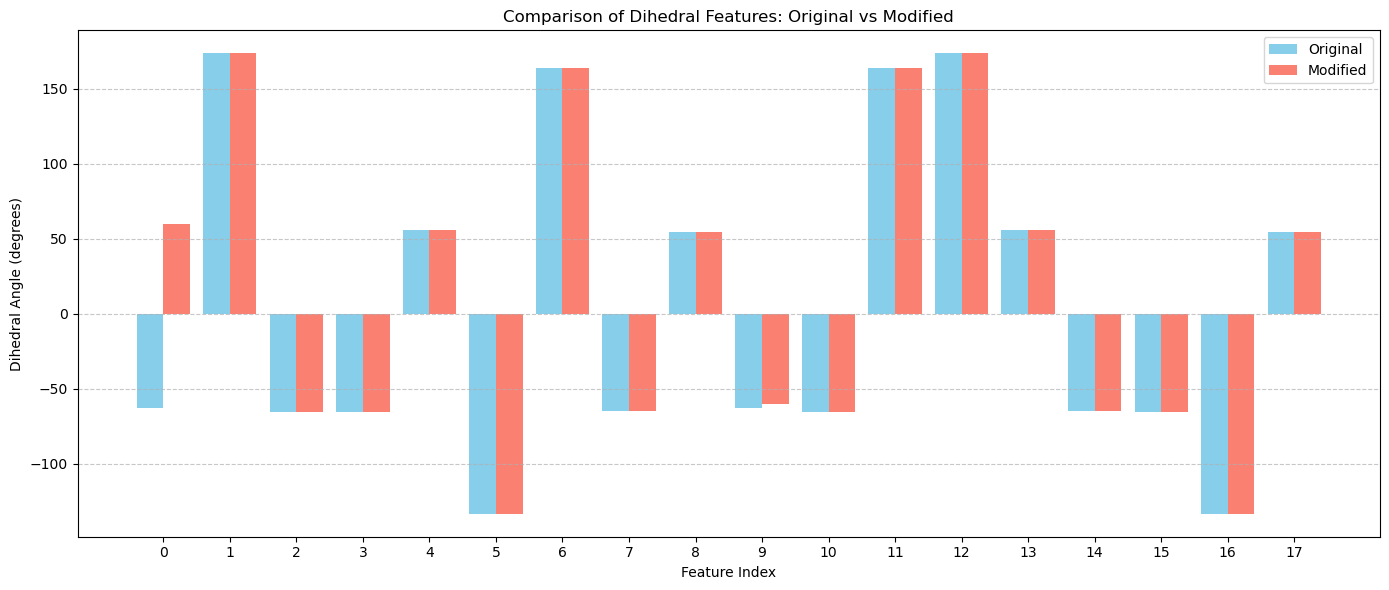

In [14]:
# Original and modified dihedral features
original = [
    -62.57826529482635, 173.6629732364575, -65.1471787726807, -65.28526908873914, 55.825257876012344, -133.18007787820912, 164.20781670009757, -64.55128481603624, 54.744703536137116, -62.57826529482635, -65.28526908873914, 164.20781670009757, 173.66297323645753, 55.825257876012344, -64.55128481603624, -65.1471787726807, -133.18007787820912, 54.744703536137116
]

modified = [
    60.0, 173.6629732364575, -65.1471787726807, -65.28526908873914, 55.825257876012344, -133.18007787820912, 164.20781670009757, -64.55128481603624, 54.744703536137116, -60.0, -65.28526908873914, 164.20781670009757, 173.66297323645753, 55.825257876012344, -64.55128481603624, -65.1471787726807, -133.18007787820912, 54.744703536137116
]

# X-axis positions
indices = np.arange(len(original))
bar_width = 0.4

# Create the bar plot
plt.figure(figsize=(14, 6))
plt.bar(indices - bar_width/2, original, width=bar_width, label='Original', color='skyblue')
plt.bar(indices + bar_width/2, modified, width=bar_width, label='Modified', color='salmon')

# Labels and formatting
plt.xlabel('Feature Index')
plt.ylabel('Dihedral Angle (degrees)')
plt.title('Comparison of Dihedral Features: Original vs Modified')
plt.xticks(indices)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
new_representation

[[[0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0.010328015711676944,
   0.33333333333333326,
   0.15789473684210525,
   1,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0],
  [0,
   0,
   0,
  